In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("C:\\Users\\Karth\\OneDrive\\Desktop\\KM\\Data Analytics\\TOPIC 10B\\uber-raw-data-apr14\\uber-raw-data-apr14.csv", parse_dates=['Date/Time'])
df.head()

,Date/Time,Lat,Lon,Base
0,2014-04-01 00:11:00,40.7690,-73.9549,B02512
1,2014-04-01 00:17:00,40.7267,-74.0345,B02512
2,2014-04-01 00:21:00,40.7316,-73.9873,B02512
3,2014-04-01 00:28:00,40.7588,-73.9776,B02512
4,2014-04-01 00:33:00,40.7594,-73.9722,B02512


In [3]:
# Extract the hour from the 'Date/Time' column to analyze hourly patterns and create a new hour column in dataframe
df['hour']=df['Date/Time'].dt.hour
# extract day of week
df['day_of_week']=df['Date/Time'].dt.dayofweek
# extract date without time
df['date']=df['Date/Time'].dt.date
# create a binary weekend indicator
df['is_weekend']=(df['day_of_week']>=5).astype(int)

print("Time features extracted: 'hour', 'day_of_week', 'date', 'is_weekend")
print(df[['Date/Time', 'hour', 'day_of_week', 'date', 'is_weekend']].head(10))

Time features extracted: 'hour', 'day_of_week', 'date', 'is_weekend
            Date/Time  hour  day_of_week        date  is_weekend
0 2014-04-01 00:11:00     0            1  2014-04-01           0
1 2014-04-01 00:17:00     0            1  2014-04-01           0
2 2014-04-01 00:21:00     0            1  2014-04-01           0
3 2014-04-01 00:28:00     0            1  2014-04-01           0
4 2014-04-01 00:33:00     0            1  2014-04-01           0
5 2014-04-01 00:33:00     0            1  2014-04-01           0
6 2014-04-01 00:39:00     0            1  2014-04-01           0
7 2014-04-01 00:45:00     0            1  2014-04-01           0
8 2014-04-01 00:55:00     0            1  2014-04-01           0
9 2014-04-01 01:01:00     1            1  2014-04-01           0


In [4]:
df.head()

,Date/Time,Lat,Lon,Base,hour,day_of_week,date,is_weekend
0,2014-04-01 00:11:00,40.7690,-73.9549,B02512,0,1,2014-04-01,0
1,2014-04-01 00:17:00,40.7267,-74.0345,B02512,0,1,2014-04-01,0
2,2014-04-01 00:21:00,40.7316,-73.9873,B02512,0,1,2014-04-01,0
3,2014-04-01 00:28:00,40.7588,-73.9776,B02512,0,1,2014-04-01,0
4,2014-04-01 00:33:00,40.7594,-73.9722,B02512,0,1,2014-04-01,0


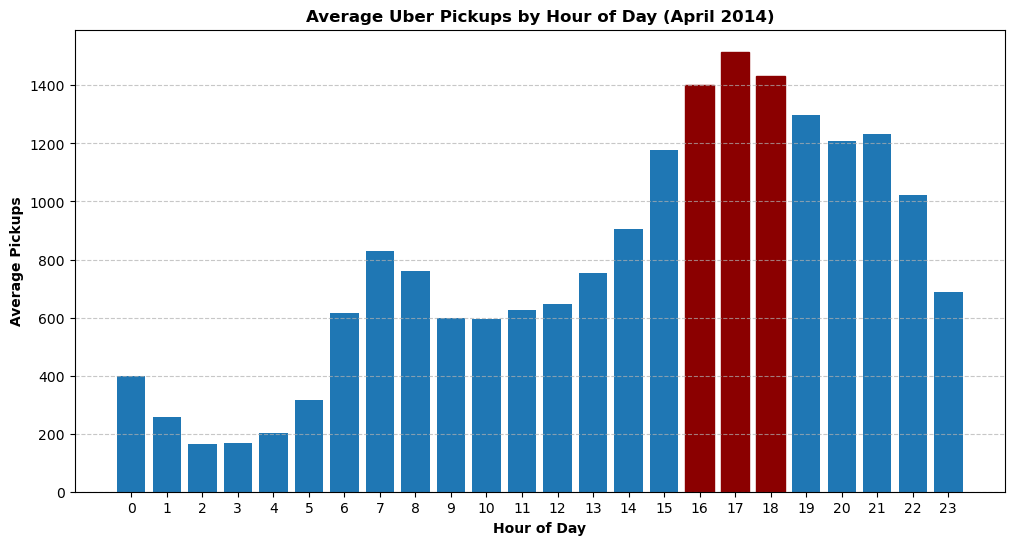

In [5]:
# Aggregate demand by hour
hourly_demand=df.groupby('hour').size().reset_index(name='total_pickups')

#average pickups by hour
num_days=df['date'].nunique()
hourly_demand['avg_pickups']=hourly_demand['total_pickups']/num_days

bars=plt.bar(hourly_demand['hour'],hourly_demand['avg_pickups'])
peak_hours=hourly_demand.nlargest(3,'avg_pickups')['hour'].values
for i, bar in enumerate(bars):
    if hourly_demand['hour'][i] in peak_hours:
        bar.set_color('darkred')

plt.title('Average Uber Pickups by Hour of Day (April 2014)',fontweight='bold')
plt.xlabel('Hour of Day',fontweight='bold')
plt.ylabel('Average Pickups',fontweight='bold')
plt.xticks(range(0,24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


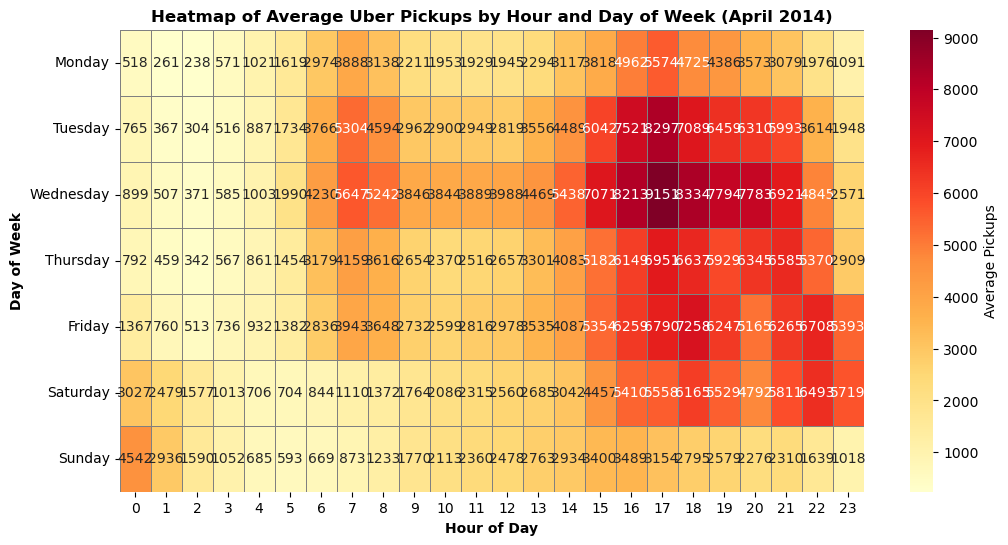

In [6]:
# create a hour day heatmap to visualize demand patterns across hours and days of week
#create pivot table
demand_matrix=df.groupby(['day_of_week','hour']).size().unstack(fill_value=0)
#Normalize by number of weeks to get the average demand
num_weeks=len(df)/7/24 /demand_matrix.mean().mean()
#daynames for y axis labels
day_names=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
#create heatmap
plt.figure(figsize=(12,6))
sns.heatmap(demand_matrix,cmap='YlOrRd', xticklabels=range(24), yticklabels=day_names, linewidths=0.5, linecolor='gray', annot=True, fmt='d', cbar_kws={'label':'Average Pickups'})
plt.title('Heatmap of Average Uber Pickups by Hour and Day of Week (April 2014)', fontweight='bold')
plt.xlabel('Hour of Day', fontweight='bold')
plt.ylabel('Day of Week', fontweight='bold')
plt.show()

# predictive analytics  


In [ ]:
# prepare data for predictive modelling
hourly_data=df.groupby(['date','hour','day_of_week','is_weekend']).size().reset_index(name='demand')
hourly_data.head()

,date,hour,day_of_week,is_weekend,demand
0,2014-04-01,0,1,0,138
1,2014-04-01,1,1,0,66
2,2014-04-01,2,1,0,53
3,2014-04-01,3,1,0,93
4,2014-04-01,4,1,0,166


In [17]:
#Define features and target variables
feature_columns=['hour','day_of_week','is_weekend']
X=hourly_data[feature_columns]
y=hourly_data['demand']
print(X.head()) 
print(y.head())

   hour  day_of_week  is_weekend
0     0            1           0
1     1            1           0
2     2            1           0
3     3            1           0
4     4            1           0
0    138
1     66
2     53
3     93
4    166
Name: demand, dtype: int64


In [19]:
#split data into training and testing sets
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
#train the predictive model using linear regression
model=LinearRegression()
model.fit(X_train,y_train)
# print model coefficients to understand feature importance
for feature,coef in zip(feature_columns,model.coef_):
    print(f"Feature: {feature}, Coefficient: {coef:.2f}")

print(f"\nBias Intercept: {model.intercept_:.2f}")


Feature: hour, Coefficient: 47.19
Feature: day_of_week, Coefficient: 46.80
Feature: is_weekend, Coefficient: -301.09

Bias Intercept: 170.63


In [21]:
print(f"\nINTERPRETATION")
print(f"- Each additional hour changes demand by {model.coef_[0]:.2f} rides - pickups on average, holding other factors constant.")
print(f"- Each day into the week changes demand by {model.coef_[1]:.2f} rides - pickups on average, holding other factors constant.")
print(f"- Weekend effect : Being a weekend changes demand by {model.coef_[2]:.2f} rides - pickups on average, holding other factors constant.")


INTERPRETATION
- Each additional hour changes demand by 47.19 rides - pickups on average, holding other factors constant.
- Each day into the week changes demand by 46.80 rides - pickups on average, holding other factors constant.
- Weekend effect : Being a weekend changes demand by -301.09 rides - pickups on average, holding other factors constant.


In [26]:
# Evaluate moedl performance using Mean Squared Error
y_pred=model.predict(X_test)
from sklearn.metrics import mean_absolute_error,r2_score
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

mse=mean_squared_error(y_test,y_pred)
print(f"\nModel Performance:")
print(f"Mean Squared Error: {mse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"R-squared: {r2:.2f}({r2*100:.1f}% of variance explained)")


Model Performance:
Mean Squared Error: 220388.83
Mean Absolute Error: 316.79
R-squared: 0.39(39.5% of variance explained)


In [27]:
print(f"\nINTERPRETATION")
print(f"- On Average predictions are off by {mae:.0f} rides per hour.")
print(f"- The model captures {r2*100:.1f}% of the variance in demand.")



INTERPRETATION
- On Average predictions are off by 317 rides per hour.
- The model captures 39.5% of the variance in demand.


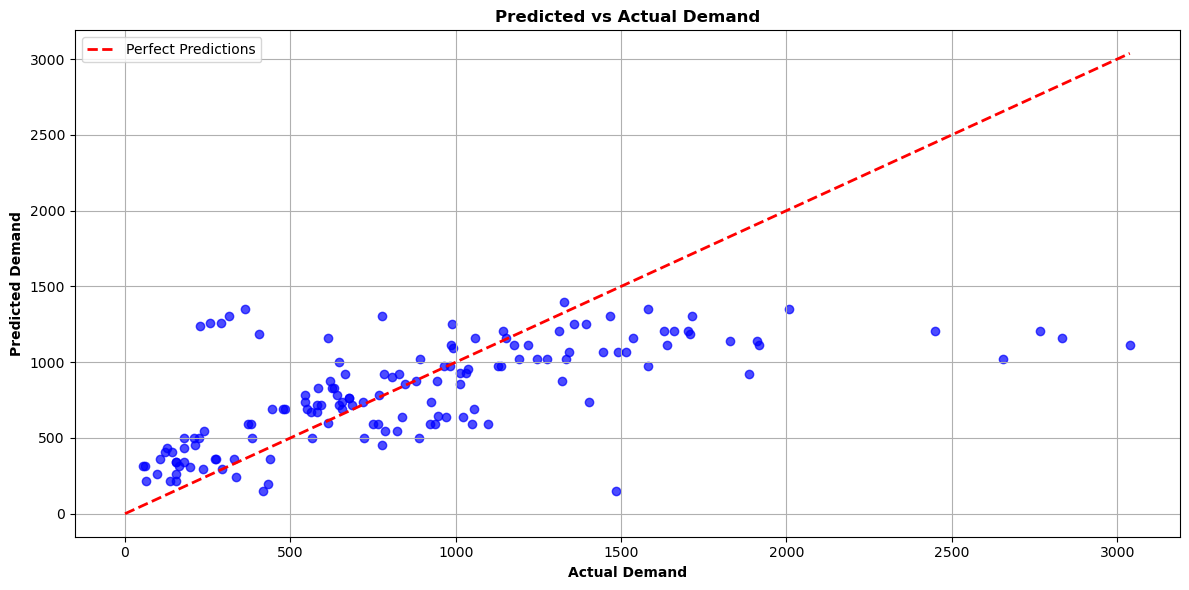

In [32]:
# Visualize predictions vs actual demand
plt.figure(figsize=(12,6))
plt.scatter(y_test,y_pred, alpha=0.7, color='blue')

#add diagonal line for perfect predictions
max_val=max(max(y_test),max(y_pred))
plt.plot([0,max_val],[0,max_val],'r--',linewidth=2, color='red', linestyle='--',label='Perfect Predictions')
plt.title('Predicted vs Actual Demand', fontweight='bold')
plt.xlabel('Actual Demand', fontweight='bold')
plt.ylabel('Predicted Demand', fontweight='bold')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


In [33]:
# Make Sample Predictions

scenarios = [
    {'hour':8, 'day_of_week':0, 'is_weekend':0, 'description': 'Monday 8 AM'},
    {'hour':14, 'day_of_week':2, 'is_weekend':0, 'description': 'Wednesday 2 PM'},
    {'hour':22, 'day_of_week':5, 'is_weekend':1, 'description': 'Saturday 10 PM'},
    {'hour':3, 'day_of_week':6, 'is_weekend':1, 'description': 'Sunday 3 AM'}
]
 
# Iterate through each test scenario

for scenario in scenarios:
    # Create a DataFrame with the scenario features for model input
    X_scenario = pd.DataFrame([{
        'hour': scenario['hour'],
        'day_of_week': scenario['day_of_week'],
        'is_weekend': scenario['is_weekend']
    }])

    # Use the trained model to predict demand for this scenario

    predicted_demand = model.predict(X_scenario)[0]
    # Display the scenario description and the predicted demand
    print(f"{scenario['description']}")
    print(f"   → Predicted demand: {predicted_demand:.0f} rides\n")
 


Monday 8 AM
   → Predicted demand: 548 rides

Wednesday 2 PM
   → Predicted demand: 925 rides

Saturday 10 PM
   → Predicted demand: 1142 rides

Sunday 3 AM
   → Predicted demand: 292 rides



# Prescriptive Analytics

In [50]:
# Define Prescriptive Business Rules
RIDES_PER_DRIVER_PER_HOUR = 3
BASE_DRIVERS = 50 
def prescribe_driver_allocation(predicted_demand, rides_per_driver=RIDES_PER_DRIVER_PER_HOUR):
    # Calculate base requirement
    drivers_needed = predicted_demand / rides_per_driver
    # Add 20% buffer
    drivers_with_buffer = drivers_needed * 1.2
    # Ensure minimum staffing
    final_recommendation = max(BASE_DRIVERS, int(np.ceil(drivers_with_buffer))) 
    return final_recommendation 
print(f"Assumption: Each driver handles {RIDES_PER_DRIVER_PER_HOUR} rides/hour")
print(f"Minimum drivers on duty: {BASE_DRIVERS}")
print("Formula: drivers = (predicted_demand * 1.2) / {}".format(RIDES_PER_DRIVER_PER_HOUR))
 


Assumption: Each driver handles 3 rides/hour
Minimum drivers on duty: 50
Formula: drivers = (predicted_demand * 1.2) / 3


In [51]:
# Define Demand Level Classification
def classify_demand_level(predicted_demand):
    if predicted_demand < 500:
        return 'LOW' , 'Standard Procedure'
    elif predicted_demand < 1000:
        return 'MODERATE', 'Standard Procedure - Monitor queque times'
    elif predicted_demand < 2000:
        return 'HIGH', 'Activate Surge Protocols'
    else:
        return 'CRITICAL', 'Maximum incentives'
 
print("THRESHOLDS:")
print(" <500 rides/hour  -> LOW")
print("  500-999 rides/hour  -> MODERATE")
print("  1000-1999 rides/hour  -> HIGH")
print("  2000+ rides/hour  -> CRITICAL") 

THRESHOLDS:
 <500 rides/hour  -> LOW
  500-999 rides/hour  -> MODERATE
  1000-1999 rides/hour  -> HIGH
  2000+ rides/hour  -> CRITICAL


In [54]:
# Complete Prescription System
def generate_prescription(hour, day_of_week, is_weekend):
 
    # Step 1: Create input for predictive model
    X_input = pd.DataFrame([{'hour': hour, 'day_of_week':day_of_week, 'is_weekend':is_weekend}])
    # Step 2: PREDICTIVE - Get demand forecast
    predicted_demand = model.predict(X_input)[0]
    # Step 3: PRESCRIPTIVE - Apply business rules
    recommended_drivers = prescribe_driver_allocation(predicted_demand)
    demand_level, recommended_action = classify_demand_level(predicted_demand)
    # Step 4: Create a prescription report
    prescription = {
    'predicted_demand':int(predicted_demand),
    'demand_level':demand_level,
    'recommended_drivers':recommended_drivers,
    'action':recommended_action
    }
 
    return prescription
 

In [55]:
# Demonstrate the complete system 
# Define test scenarios with different time and day conditions
test_scenarios = [

    {'hour':8, 'day_of_week':0, 'is_weekend':0, 'description': 'Monday Morning Rush'},
    {'hour':14, 'day_of_week':2, 'is_weekend':0, 'description': 'Wednesday Afternoon'},
    {'hour':22, 'day_of_week':5, 'is_weekend':1, 'description': 'Saturday Night'},
    {'hour':18, 'day_of_week':4, 'is_weekend':0, 'description': 'Friday Evening Rush'}
]
 
# Iterate through each test scenario
for scenario in test_scenarios:
    # Generate prescription based on the current scenario parameters
    rx = generate_prescription(
        hour=scenario['hour'],
        day_of_week=scenario['day_of_week'],
        is_weekend=scenario['is_weekend']
    )
     # Print scenario description
    print(f"SCENARIO: {scenario['description']}")
    # Print prediction results
    print(f"\n PREDICTED OUTPUT :")
    print(f" Expected Demand: {rx['predicted_demand']} rides/hour")
    print(f" Demand Level: {rx['demand_level']}")
    # Print prescription recommendations
    print(f"\n PRESCRIPTIVE OUTPUT :")
    print(f"  Deploy: {rx['recommended_drivers']} rides/hour")
    print(f"  Action: {rx['action']}")
 
 


SCENARIO: Monday Morning Rush

 PREDICTED OUTPUT :
 Expected Demand: 548 rides/hour
 Demand Level: MODERATE

 PRESCRIPTIVE OUTPUT :
  Deploy: 220 rides/hour
  Action: Standard Procedure - Monitor queque times
SCENARIO: Wednesday Afternoon

 PREDICTED OUTPUT :
 Expected Demand: 924 rides/hour
 Demand Level: MODERATE

 PRESCRIPTIVE OUTPUT :
  Deploy: 370 rides/hour
  Action: Standard Procedure - Monitor queque times
SCENARIO: Saturday Night

 PREDICTED OUTPUT :
 Expected Demand: 1141 rides/hour
 Demand Level: HIGH

 PRESCRIPTIVE OUTPUT :
  Deploy: 457 rides/hour
  Action: Activate Surge Protocols
SCENARIO: Friday Evening Rush

 PREDICTED OUTPUT :
 Expected Demand: 1207 rides/hour
 Demand Level: HIGH

 PRESCRIPTIVE OUTPUT :
  Deploy: 483 rides/hour
  Action: Activate Surge Protocols
